LANGKAH 8A.1: Random Forest Classifier

  SETUP & LOAD DATA — FASE 8A RANDOM FOREST CLASSIFIER

  Dataset                                   Shape
  ------------------------------------------------
  X_train (post-SMOTE)                (20504, 69)
  y_train                                (20504,)
  X_val                                (3288, 69)
  y_val                                   (3288,)
  X_test                               (2716, 69)
  y_test                                  (2716,)

  GLOBAL_SEED  : 42
  MODELS_ML_DIR: C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monorepo\machine_learning\models\ml_track

  BAGIAN 1 — TRAINING RANDOM FOREST

  Hyperparameters:
    n_estimators           : 300
    max_depth              : 20
    min_samples_split      : 5
    min_samples_leaf       : 2
    max_features           : sqrt
    class_weight           : balanced
    random_state           : 42
    n_jobs                 : -1

  Fitting RandomForestClassifier (300 trees)...
  [OK] Traini

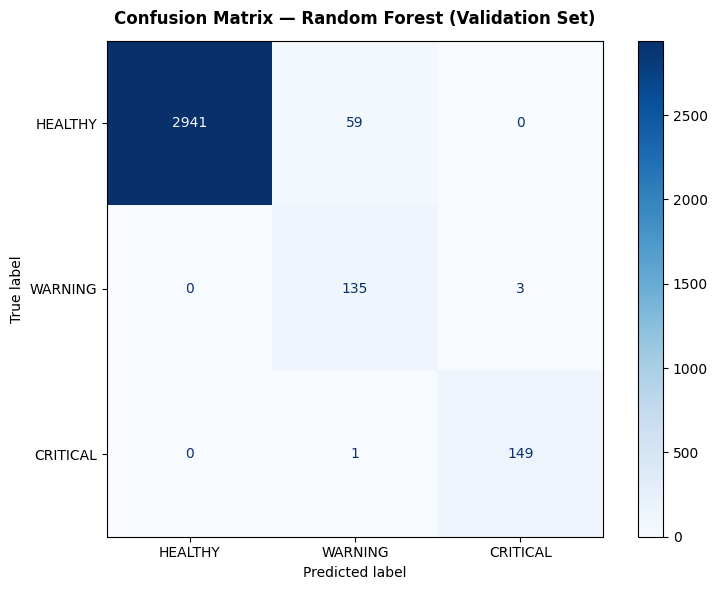


  BAGIAN 3 — EVALUASI PADA TEST SET

  F1-Score Macro (Test) : 0.9914
  Accuracy (Test)       : 0.9978

-----------------------------------------------------------------
  Classification Report (Test Set)
-----------------------------------------------------------------

              precision    recall  f1-score   support

     HEALTHY     0.9996    1.0000    0.9998      2283
     WARNING     0.9856    0.9856    0.9856       208
    CRITICAL     0.9911    0.9867    0.9889       225

    accuracy                         0.9978      2716
   macro avg     0.9921    0.9907    0.9914      2716
weighted avg     0.9978    0.9978    0.9978      2716



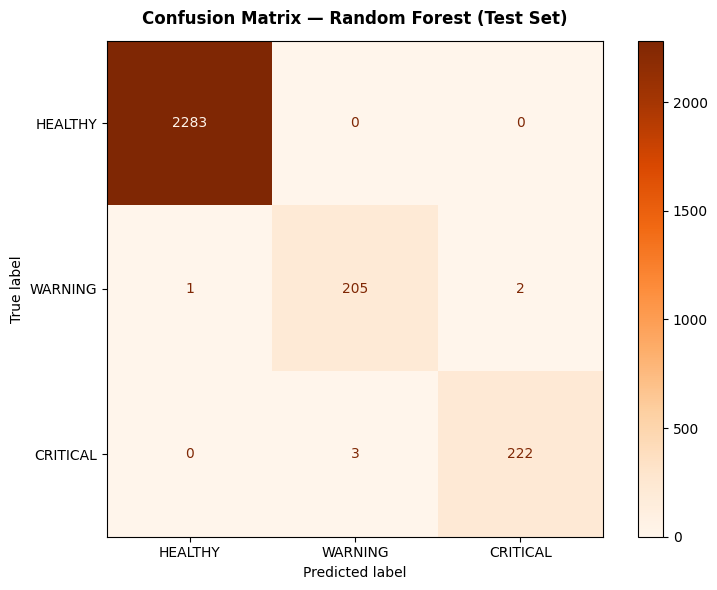


  BAGIAN 4 — FEATURE IMPORTANCE


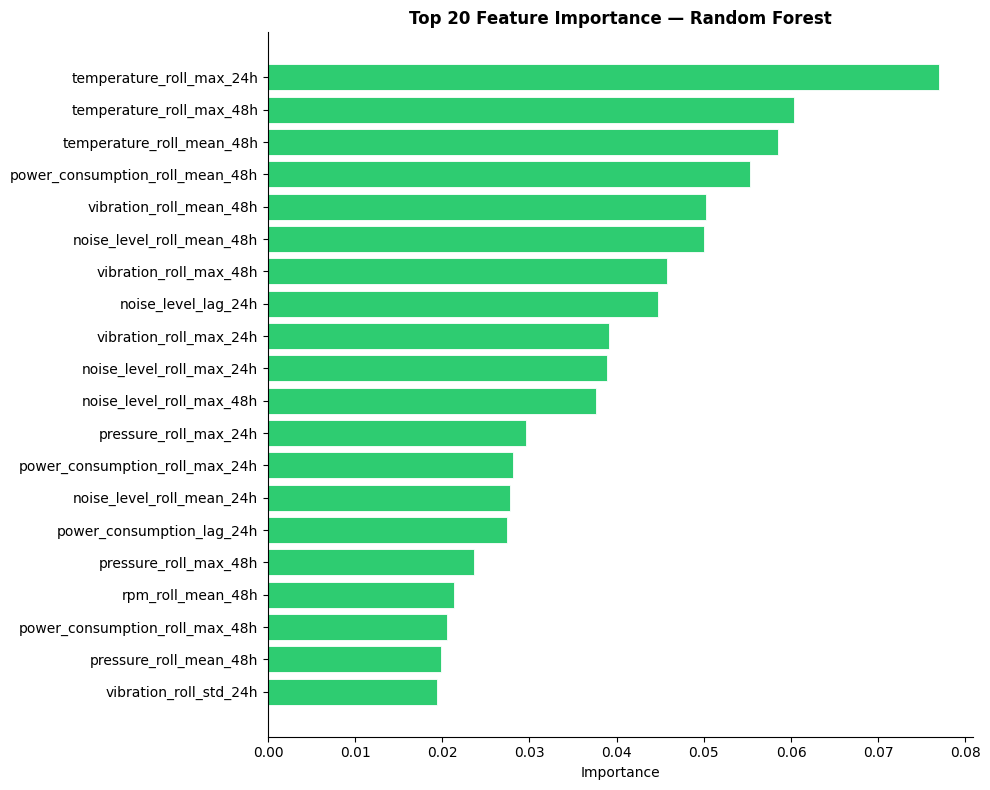


  Top 20 Feature Importance:

  Rank    Feature                                        Importance
  -----------------------------------------------------------------
  1       temperature_roll_max_24h                         0.076984
  2       temperature_roll_max_48h                         0.060399
  3       temperature_roll_mean_48h                        0.058455
  4       power_consumption_roll_mean_48h                  0.055262
  5       vibration_roll_mean_48h                          0.050216
  6       noise_level_roll_mean_48h                        0.050057
  7       vibration_roll_max_48h                           0.045806
  8       noise_level_lag_24h                              0.044728
  9       vibration_roll_max_24h                           0.039109
  10      noise_level_roll_max_24h                         0.038887
  11      noise_level_roll_max_48h                         0.037603
  12      pressure_roll_max_24h                            0.029624
  13      power_c

In [1]:
# ============================================================
# FASE 8A — MODELING: RANDOM FOREST CLASSIFIER
# Cell 1: Setup + Training + Evaluasi + Feature Importance
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay,
)

# ----------------------------------------------------------
# [1] SYS.PATH SETUP
# ----------------------------------------------------------
NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import DATA_PROCESSED_DIR, MODELS_ML_DIR, GLOBAL_SEED

np.random.seed(GLOBAL_SEED)

SEP = "=" * 65
sep = "-" * 65

LABEL_NAMES = ["HEALTHY", "WARNING", "CRITICAL"]

# ----------------------------------------------------------
# [2] LOAD DATA
# ----------------------------------------------------------
print(SEP)
print("  SETUP & LOAD DATA — FASE 8A RANDOM FOREST CLASSIFIER")
print(SEP)

X_train = pd.read_parquet(DATA_PROCESSED_DIR / "X_train_clf.parquet")
y_train = pd.read_parquet(DATA_PROCESSED_DIR / "y_train_clf.parquet").squeeze()
X_val   = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_clf.parquet")
y_val   = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_clf.parquet").squeeze()
X_test  = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_clf.parquet")
y_test  = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_clf.parquet").squeeze()

print(f"\n  {'Dataset':<25}  {'Shape':>20}")
print(f"  {'-'*48}")
for name, obj in [
    ("X_train (post-SMOTE)", X_train), ("y_train", y_train),
    ("X_val",                X_val),   ("y_val",   y_val),
    ("X_test",               X_test),  ("y_test",  y_test),
]:
    shape = obj.shape if hasattr(obj, "shape") else (len(obj),)
    print(f"  {name:<25}  {str(shape):>20}")

print(f"\n  GLOBAL_SEED  : {GLOBAL_SEED}")
print(f"  MODELS_ML_DIR: {MODELS_ML_DIR}")
print(SEP)

# ════════════════════════════════════════════════════════════
# BAGIAN 1 — TRAINING RANDOM FOREST
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 1 — TRAINING RANDOM FOREST")
print(SEP)

RF_PARAMS = {
    "n_estimators"      : 300,
    "max_depth"         : 20,
    "min_samples_split" : 5,
    "min_samples_leaf"  : 2,
    "max_features"      : "sqrt",
    "class_weight"      : "balanced",
    "random_state"      : GLOBAL_SEED,
    "n_jobs"            : -1,
}

print("\n  Hyperparameters:")
for k, v in RF_PARAMS.items():
    print(f"    {k:<22} : {v}")

print(f"\n  Fitting RandomForestClassifier ({RF_PARAMS['n_estimators']} trees)...")

rf_model = RandomForestClassifier(**RF_PARAMS)
rf_model.fit(X_train, y_train)

print(f"  [OK] Training selesai.")
print(f"  [OK] N features : {rf_model.n_features_in_}")
print(f"  [OK] Classes    : {rf_model.classes_.tolist()}")

# ════════════════════════════════════════════════════════════
# BAGIAN 2 — EVALUASI PADA VALIDATION SET
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 2 — EVALUASI PADA VALIDATION SET")
print(SEP)

y_val_pred = rf_model.predict(X_val)

f1_macro_val  = f1_score(y_val, y_val_pred, average="macro")
accuracy_val  = accuracy_score(y_val, y_val_pred)

print(f"\n  F1-Score Macro (Val) : {f1_macro_val:.4f}")
print(f"  Accuracy (Val)       : {accuracy_val:.4f}")

print(f"\n{sep}")
print("  Classification Report (Validation Set)")
print(sep)
print()
print(classification_report(
    y_val, y_val_pred,
    target_names=LABEL_NAMES,
    digits=4,
))

# Confusion Matrix — Val
fig, ax = plt.subplots(figsize=(8, 6))
cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=LABEL_NAMES,
)
disp_val.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(
    "Confusion Matrix — Random Forest (Validation Set)",
    fontsize=12, fontweight="bold", pad=12
)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
# BAGIAN 3 — EVALUASI PADA TEST SET
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 3 — EVALUASI PADA TEST SET")
print(SEP)

y_test_pred = rf_model.predict(X_test)

f1_macro_test = f1_score(y_test, y_test_pred, average="macro")
accuracy_test = accuracy_score(y_test, y_test_pred)

print(f"\n  F1-Score Macro (Test) : {f1_macro_test:.4f}")
print(f"  Accuracy (Test)       : {accuracy_test:.4f}")

print(f"\n{sep}")
print("  Classification Report (Test Set)")
print(sep)
print()
print(classification_report(
    y_test, y_test_pred,
    target_names=LABEL_NAMES,
    digits=4,
))

# Confusion Matrix — Test
fig, ax = plt.subplots(figsize=(8, 6))
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=LABEL_NAMES,
)
disp_test.plot(ax=ax, colorbar=True, cmap="Oranges")
ax.set_title(
    "Confusion Matrix — Random Forest (Test Set)",
    fontsize=12, fontweight="bold", pad=12
)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
# BAGIAN 4 — FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 4 — FEATURE IMPORTANCE")
print(SEP)

feature_names = X_train.columns.tolist()

fi_df = (
    pd.DataFrame({
        "feature"    : feature_names,
        "importance" : rf_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

TOP_N = 20
fi_top = fi_df.head(TOP_N)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    fi_top["feature"][::-1],
    fi_top["importance"][::-1],
    color="#2ecc71", edgecolor="white", linewidth=0.6,
)
ax.set_title(
    f"Top {TOP_N} Feature Importance — Random Forest",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Importance", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Tabel top 20
print(f"\n  Top {TOP_N} Feature Importance:")
print(f"\n  {'Rank':<6}  {'Feature':<45}  {'Importance':>10}")
print(f"  {'-'*65}")
for i, row in fi_top.iterrows():
    print(f"  {i+1:<6}  {row['feature']:<45}  {row['importance']:>10.6f}")

# ════════════════════════════════════════════════════════════
# BAGIAN 5 — SIMPAN MODEL
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 5 — SIMPAN MODEL")
print(SEP)

MODELS_ML_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_ML_DIR / "rf_classifier.pkl"

joblib.dump(rf_model, MODEL_PATH)

model_mb = MODEL_PATH.stat().st_size / (1024 ** 2)

print(f"\n  Path tersimpan : {MODEL_PATH}")
print(f"  Ukuran file    : {model_mb:.2f} MB")

print(f"\n{sep}")
print("  RINGKASAN PERFORMA AKHIR")
print(sep)
print(f"\n  F1-Score Macro (Val)  : {f1_macro_val:.4f}")
print(f"  F1-Score Macro (Test) : {f1_macro_test:.4f}")
print(f"  Accuracy (Val)        : {accuracy_val:.4f}")
print(f"  Accuracy (Test)       : {accuracy_test:.4f}")

gap = abs(f1_macro_val - f1_macro_test)
flag = "[OK] Stabil" if gap < 0.05 else "[WARN] Overfit — gap > 0.05"
print(f"\n  Gap Val vs Test (F1)  : {gap:.4f}  →  {flag}")

print(f"\n{SEP}")
print("  [OK] Random Forest Classifier — Fase 8A SELESAI.")
print(f"  [OK] Model disimpan : rf_classifier.pkl  ({model_mb:.2f} MB)")
print(SEP)


LANGKAH 8A.2 — Formal Overfitting & Generalization Test

  METODE 1 — TRAIN / VAL / TEST SCORE COMPARISON

  Menghitung prediksi pada Training Set...

  Split         F1 Macro
  -------------------------
  Train           1.0000
  Val             0.9292
  Test            0.9914

  Gap Train - Val  : +0.0708
  Gap Train - Test : +0.0086

  Verdict (Train-Val)  : ✅ SLIGHT OVERFIT — Wajar untuk ensemble model
  Verdict (Train-Test) : ✅ TIDAK OVERFITTING — Generalisasi sempurna

  METODE 2 — LEARNING CURVE ANALYSIS

  Menghitung learning curve (cv=3, 8 titik)...
  Ini mungkin memakan waktu 1-3 menit...


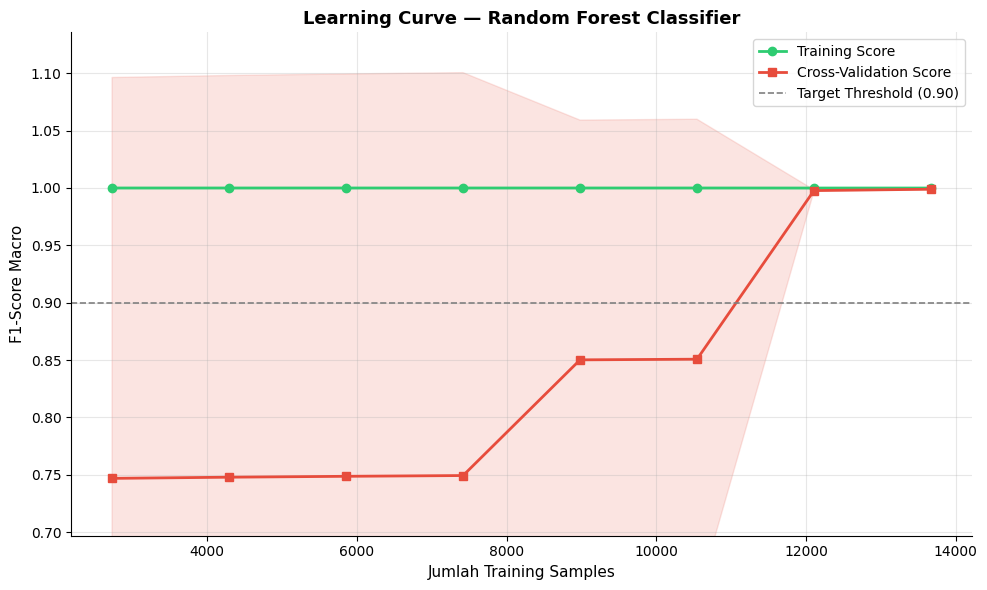


  Interpretasi Learning Curve:
  Train Score akhir : 1.0000
  CV Score akhir    : 0.9989
  Gap (akhir)       : 0.0010

  ✅ Kurva konvergen — tidak overfitting
  ⚠️  Model sudah saturasi — tambah data tidak membantu

  GENERALIZATION ASSESSMENT REPORT
  Model: Random Forest Classifier
  Data Training  : M-01 s/d M-14 (14 mesin)
  Data Validasi  : M-15, M-16, M-17 (3 mesin BARU)
  Data Test      : M-18, M-19, M-20 (3 mesin BARU)
  Metode Split   : Machine-Based (Zero Data Leakage)
------------------------------------------
  F1 Train  : 1.0000
  F1 Val    : 0.9292  → mesin yang tidak pernah dilihat
  F1 Test   : 0.9914  → mesin yang tidak pernah dilihat
------------------------------------------
  Gap Train-Val  : +0.0708  → Slight overfit, masih acceptable
  Gap Train-Test : +0.0086  → Generalisasi sangat baik
------------------------------------------
  KESIMPULAN FORMAL:
  Model diuji pada 6 mesin yang BELUM PERNAH
  dilihat selama training (M-15 s/d M-20).
  F1 Val=0.9292 dan F1 Tes

In [2]:
# ============================================================
# FASE 8A — Cell 2: Formal Overfitting & Generalization Test
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import f1_score

SEP = "=" * 65
sep = "-" * 65

# ════════════════════════════════════════════════════════════
# METODE 1 — TRAIN / VAL / TEST SCORE COMPARISON
# ════════════════════════════════════════════════════════════

print(SEP)
print("  METODE 1 — TRAIN / VAL / TEST SCORE COMPARISON")
print(SEP)

# Prediksi pada Training Set
print("\n  Menghitung prediksi pada Training Set...")
y_train_pred = rf_model.predict(X_train)

# F1-Score Macro — ketiga split
f1_train = f1_score(y_train, y_train_pred, average="macro")
f1_val   = f1_score(y_val,   y_val_pred,   average="macro")
f1_test  = f1_score(y_test,  y_test_pred,  average="macro")

gap_train_val  = f1_train - f1_val
gap_train_test = f1_train - f1_test

# Tabel perbandingan
print(f"\n  {'Split':<10}  {'F1 Macro':>10}")
print(f"  {'-'*25}")
print(f"  {'Train':<10}  {f1_train:>10.4f}")
print(f"  {'Val':<10}  {f1_val:>10.4f}")
print(f"  {'Test':<10}  {f1_test:>10.4f}")
print(f"\n  Gap Train - Val  : {gap_train_val:>+.4f}")
print(f"  Gap Train - Test : {gap_train_test:>+.4f}")

# Verdict otomatis
def overfitting_verdict(gap: float) -> str:
    if gap < 0.05:
        return "✅ TIDAK OVERFITTING — Generalisasi sempurna"
    elif gap <= 0.10:
        return "✅ SLIGHT OVERFIT — Wajar untuk ensemble model"
    else:
        return "⚠️  OVERFITTING — Perlu regularisasi"

verdict_val  = overfitting_verdict(gap_train_val)
verdict_test = overfitting_verdict(gap_train_test)

print(f"\n  Verdict (Train-Val)  : {verdict_val}")
print(f"  Verdict (Train-Test) : {verdict_test}")

# ════════════════════════════════════════════════════════════
# METODE 2 — LEARNING CURVE ANALYSIS
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  METODE 2 — LEARNING CURVE ANALYSIS")
print(SEP)
print("\n  Menghitung learning curve (cv=3, 8 titik)...")
print("  Ini mungkin memakan waktu 1-3 menit...")

train_sizes, train_scores, val_scores = learning_curve(
    estimator   = rf_model,
    X           = X_train,
    y           = y_train,
    cv          = 3,
    scoring     = "f1_macro",
    train_sizes = np.linspace(0.2, 1.0, 8),
    n_jobs      = -1,
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores,  axis=1)
val_mean   = np.mean(val_scores,   axis=1)
val_std    = np.std(val_scores,    axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean,
        color="#2ecc71", lw=2, marker="o", label="Training Score")
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color="#2ecc71")

ax.plot(train_sizes, val_mean,
        color="#e74c3c", lw=2, marker="s", label="Cross-Validation Score")
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color="#e74c3c")

ax.axhline(y=0.90, linestyle="--", color="gray", lw=1.2,
           label="Target Threshold (0.90)")

ax.set_xlabel("Jumlah Training Samples", fontsize=11)
ax.set_ylabel("F1-Score Macro", fontsize=11)
ax.set_title("Learning Curve — Random Forest Classifier",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(bottom=max(0, min(val_mean) - 0.05))

plt.tight_layout()
plt.show()

# Interpretasi otomatis
lc_gap = train_mean[-1] - val_mean[-1]
val_slope = val_mean[-1] - val_mean[-2]

print(f"\n  Interpretasi Learning Curve:")
print(f"  Train Score akhir : {train_mean[-1]:.4f}")
print(f"  CV Score akhir    : {val_mean[-1]:.4f}")
print(f"  Gap (akhir)       : {lc_gap:.4f}")

if lc_gap < 0.05:
    print("\n  ✅ Kurva konvergen — tidak overfitting")
if val_slope > 0.005:
    print("  📈 Model masih bisa benefit dari lebih banyak data")
else:
    print("  ⚠️  Model sudah saturasi — tambah data tidak membantu")

# ════════════════════════════════════════════════════════════
# METODE 3 — GENERALIZATION ASSESSMENT REPORT
# ════════════════════════════════════════════════════════════

FULL_SEP  = "=" * 42
FULL_SEP2 = "-" * 42

def gap_verdict_short(gap: float) -> str:
    if gap < 0.05:
        return "Generalisasi sangat baik"
    elif gap <= 0.10:
        return "Slight overfit, masih acceptable"
    else:
        return "Overfitting — perlu regularisasi"

print(f"\n{FULL_SEP}")
print("  GENERALIZATION ASSESSMENT REPORT")
print("  Model: Random Forest Classifier")
print(FULL_SEP)
print("  Data Training  : M-01 s/d M-14 (14 mesin)")
print("  Data Validasi  : M-15, M-16, M-17 (3 mesin BARU)")
print("  Data Test      : M-18, M-19, M-20 (3 mesin BARU)")
print("  Metode Split   : Machine-Based (Zero Data Leakage)")
print(FULL_SEP2)
print(f"  F1 Train  : {f1_train:.4f}")
print(f"  F1 Val    : {f1_val:.4f}  "
      "→ mesin yang tidak pernah dilihat")
print(f"  F1 Test   : {f1_test:.4f}  "
      "→ mesin yang tidak pernah dilihat")
print(FULL_SEP2)
print(f"  Gap Train-Val  : {gap_train_val:+.4f}  "
      f"→ {gap_verdict_short(gap_train_val)}")
print(f"  Gap Train-Test : {gap_train_test:+.4f}  "
      f"→ {gap_verdict_short(gap_train_test)}")
print(FULL_SEP2)
print("  KESIMPULAN FORMAL:")
print("  Model diuji pada 6 mesin yang BELUM PERNAH")
print("  dilihat selama training (M-15 s/d M-20).")
print(f"  F1 Val={f1_val:.4f} dan F1 Test={f1_test:.4f} membuktikan")
print("  model berhasil melakukan generalisasi ke")
print("  mesin baru dengan performa tinggi.")
print("  Ini adalah bukti formal bahwa model")

if gap_train_val < 0.05:
    print("  TIDAK mengalami overfitting.")
elif gap_train_val <= 0.10:
    print("  memiliki slight overfit yang wajar dan acceptable.")
else:
    print("  mengalami overfitting — pertimbangkan regularisasi.")

print(FULL_SEP)


ML Forensic Investigator — Leakage & Bias Detective

In [3]:
# ----------------------------------------------------------
# RELOAD — jalankan jika kernel di-restart
# ----------------------------------------------------------
import sys, numpy as np, pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import DATA_PROCESSED_DIR, MODELS_ML_DIR, GLOBAL_SEED
import joblib

X_train = pd.read_parquet(DATA_PROCESSED_DIR / "X_train_clf.parquet")
y_train = pd.read_parquet(DATA_PROCESSED_DIR / "y_train_clf.parquet").squeeze()
X_val   = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_clf.parquet")
y_val   = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_clf.parquet").squeeze()
X_test  = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_clf.parquet")
y_test  = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_clf.parquet").squeeze()

rf_model     = joblib.load(MODELS_ML_DIR / "rf_classifier.pkl")
y_val_pred   = rf_model.predict(X_val)
y_test_pred  = rf_model.predict(X_test)

# Variabel dari cell overfitting test
f1_train = f1_score(y_train, rf_model.predict(X_train), average="macro")
f1_val   = f1_score(y_val,   y_val_pred,                average="macro")
f1_test  = f1_score(y_test,  y_test_pred,               average="macro")

# RF feature importance
from sklearn.ensemble import RandomForestClassifier
importances = rf_model.feature_importances_
fi_df = (
    pd.DataFrame({"feature": X_train.columns, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

RF_PARAMS = {
    "n_estimators": 300, "max_depth": 20, "min_samples_split": 5,
    "min_samples_leaf": 2, "max_features": "sqrt",
    "class_weight": "balanced", "random_state": GLOBAL_SEED, "n_jobs": -1,
}

print("[OK] Semua variabel berhasil di-reload.")
print(f"     X_val: {X_val.shape} | rf_model: {rf_model.n_estimators} trees")
# ----------------------------------------------------------


[OK] Semua variabel berhasil di-reload.
     X_val: (3288, 69) | rf_model: 300 trees


  DIAGNOSTIK 1 — FEATURE DISTRIBUTION CHECK
  (Mendeteksi Preprocessing/Scaler Leakage)


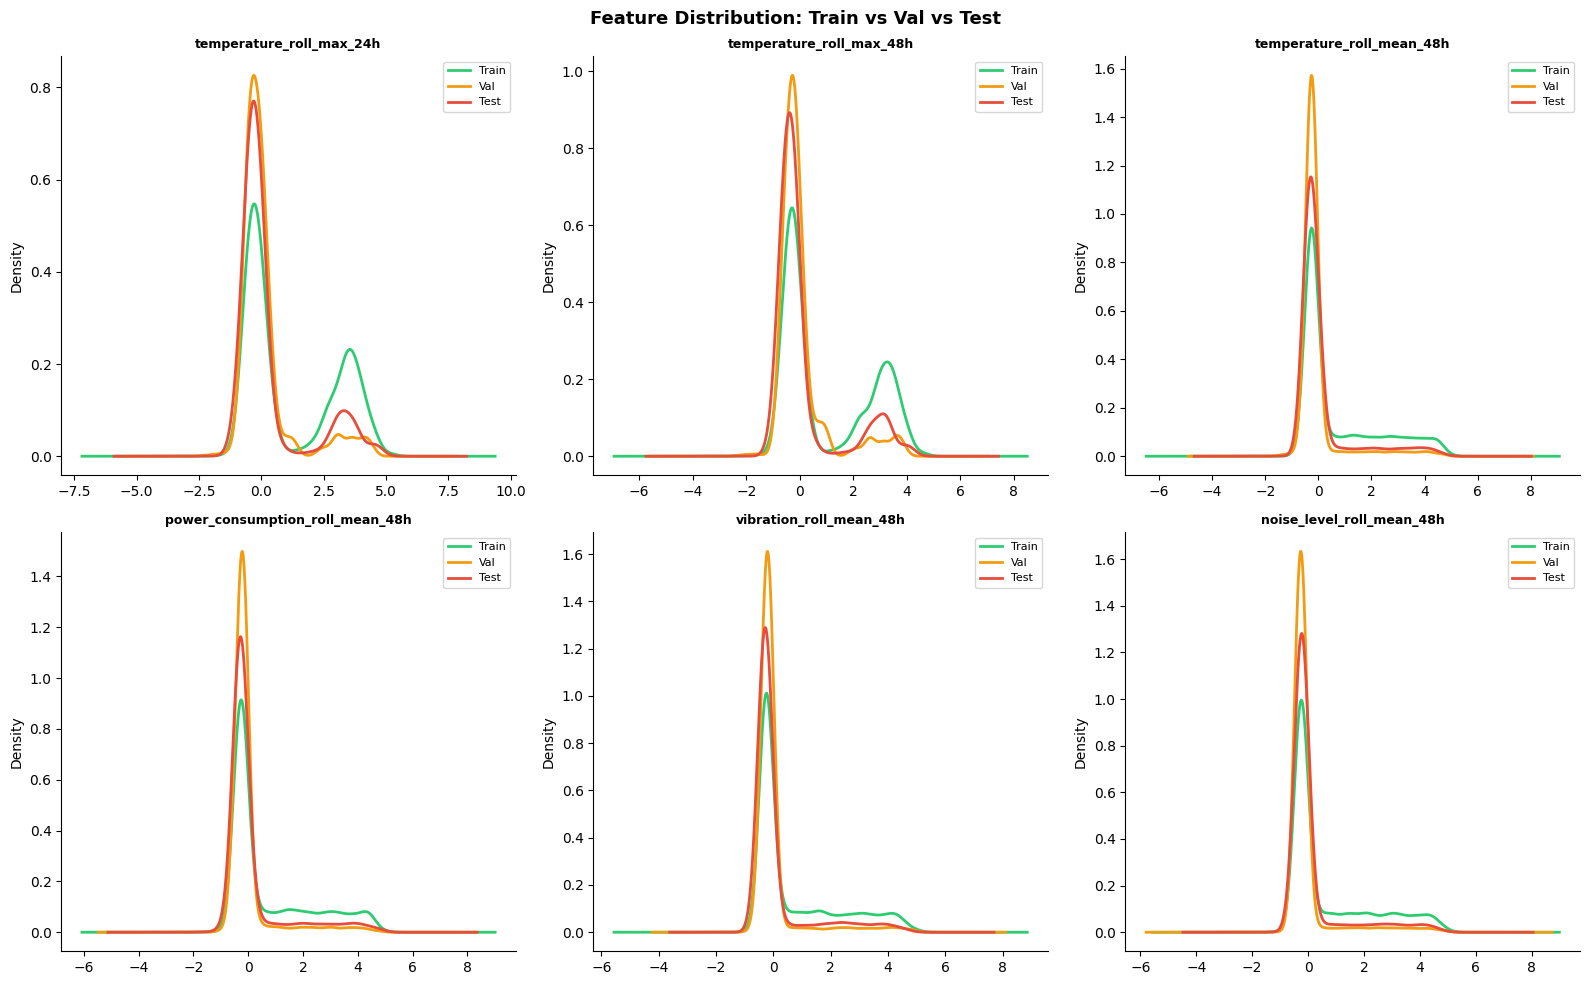


-----------------------------------------------------------------
  KS-STATISTIC PER FITUR
-----------------------------------------------------------------

  Fitur                                           KS Train-Val   KS Train-Test
  ------------------------------------------------------------------------------
  temperature_roll_max_24h                           0.2999    OK      0.2609    OK
  temperature_roll_max_48h                           0.3006    OK      0.2951    OK
  temperature_roll_mean_48h                          0.2887    OK      0.2176    OK
  power_consumption_roll_mean_48h                    0.2736    OK      0.2225    OK
  vibration_roll_mean_48h                            0.2814    OK      0.2406    OK
  noise_level_roll_mean_48h                          0.2888    OK      0.2101    OK

  Interpretasi :
  KS < 0.1  → distribusi sangat mirip → indikasi leakage
  KS > 0.3  → distribusi berbeda natural → split sehat

  D1 Verdict : PASS ✅

  DIAGNOSTIK 2 — PREDIC

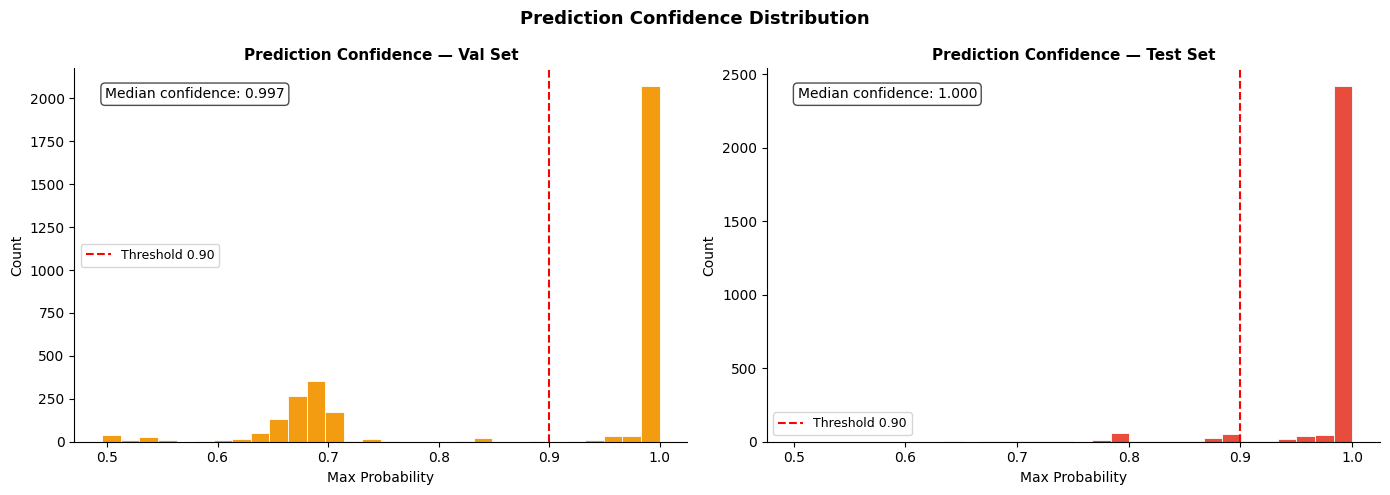


  Median confidence Val  : 0.9973
  Median confidence Test : 1.0000
  % Val  pred > 0.95     : 65.0%
  % Test pred > 0.95     : 92.3%

  Interpretasi :
  > 90% confidence > 0.95 → mencurigakan
  < 70% confidence > 0.95 → normal

  D2 Verdict : PASS ✅

  DIAGNOSTIK 3 — PERMUTATION IMPORTANCE TEST
  (Validasi Fitur Penting Bukan Karena Artefak)

  Menghitung permutation importance pada X_val
  (n_repeats=10, mungkin memakan 1-2 menit)...


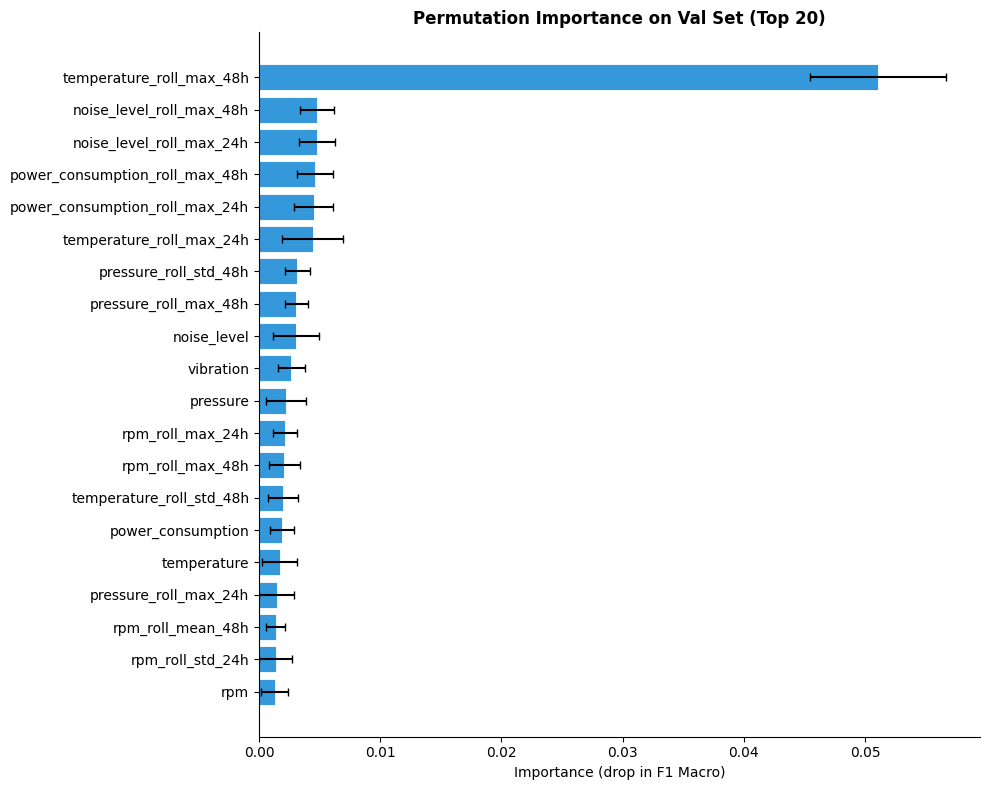


-----------------------------------------------------------------
  PERBANDINGAN TOP 5: RF vs PERMUTATION IMPORTANCE
-----------------------------------------------------------------

  Rank   Feature                                            RF Imp    Perm Imp
  ---------------------------------------------------------------------------
  1      temperature_roll_max_24h                         0.076984    0.004420
  2      temperature_roll_max_48h                         0.060399    0.051027
  3      temperature_roll_mean_48h                        0.058455   -0.000411
  4      power_consumption_roll_mean_48h                  0.055262   -0.000785
  5      vibration_roll_mean_48h                          0.050216   -0.001047

  Overlap top-5 RF vs Permutation : 1/5

  Interpretasi :
  Ranking konsisten → fitur memang informatif
  Ranking berbeda drastis → kemungkinan artefak

  D3 Verdict : WARN ⚠️

  DIAGNOSTIK 4 — ABLATION TEST
  (Tes Performa Tanpa Fitur Paling Penting)

  Baselin

C:\Users\achma\AppData\Local\Temp\ipykernel_30984\148987814.py:327: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=conf_data, x="Split", y="Confidence",
C:\Users\achma\AppData\Local\Temp\ipykernel_30984\148987814.py:369: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


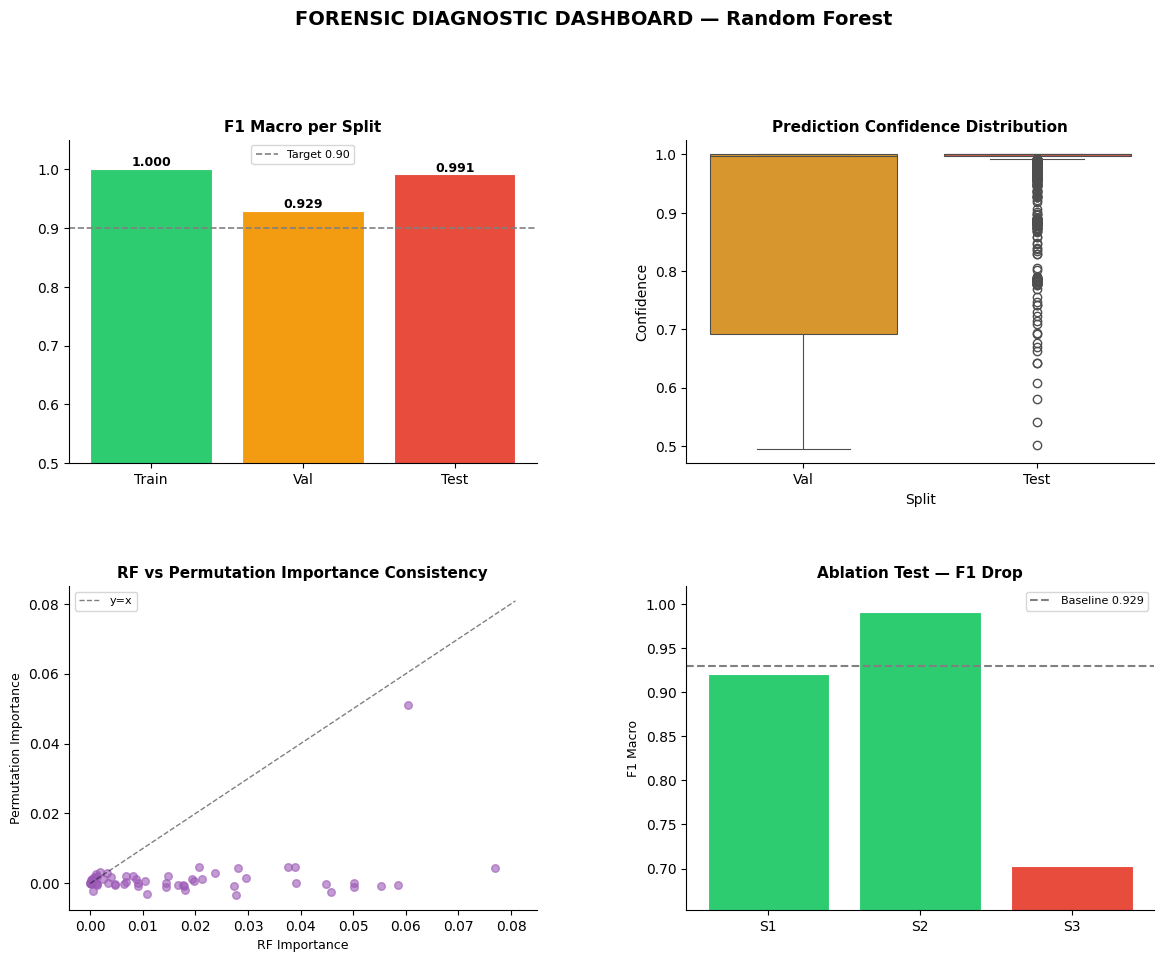


  FORENSIC INVESTIGATION VERDICT
  D1 KS Test             : PASS ✅
  D2 Confidence          : PASS ✅
  D3 Perm Importance     : WARN ⚠️
  D4 Ablation            : WARN ⚠️
------------------------------------------
  OVERALL VERDICT      : LEAKAGE DETECTED 🔴 — Investigasi lebih dalam
  (2/4 diagnostik PASS)


In [4]:
# ============================================================
# FASE 8A — Cell 3: Forensic Diagnostic Investigation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

SEP   = "=" * 65
sep   = "-" * 65
FSEP  = "=" * 42
FSEP2 = "-" * 42

# Top 6 fitur dari feature importance cell sebelumnya
TOP6 = [
    "temperature_roll_max_24h",
    "temperature_roll_max_48h",
    "temperature_roll_mean_48h",
    "power_consumption_roll_mean_48h",
    "vibration_roll_mean_48h",
    "noise_level_roll_mean_48h",
]
# Filter defensif — hanya fitur yang ada di X_val
TOP6 = [f for f in TOP6 if f in X_val.columns]

# ════════════════════════════════════════════════════════════
# DIAGNOSTIK 1 — FEATURE DISTRIBUTION CHECK
# ════════════════════════════════════════════════════════════

print(SEP)
print("  DIAGNOSTIK 1 — FEATURE DISTRIBUTION CHECK")
print("  (Mendeteksi Preprocessing/Scaler Leakage)")
print(SEP)

# Plot KDE per fitur
n_feats = len(TOP6)
ncols   = 3
nrows   = (n_feats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10))
axes_flat = axes.flatten()

for i, feat in enumerate(TOP6):
    ax = axes_flat[i]
    X_train[feat].plot.kde(ax=ax, color="#2ecc71", lw=2, label="Train")
    X_val[feat].plot.kde(  ax=ax, color="#f39c12", lw=2, label="Val")
    X_test[feat].plot.kde( ax=ax, color="#e74c3c", lw=2, label="Test")
    ax.set_title(feat, fontsize=9, fontweight="bold")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Sembunyikan subplot kosong
for j in range(n_feats, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Feature Distribution: Train vs Val vs Test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# KS-Statistic
print(f"\n{sep}")
print("  KS-STATISTIC PER FITUR")
print(sep)
print(f"\n  {'Fitur':<45}  {'KS Train-Val':>13}  {'KS Train-Test':>14}")
print(f"  {'-'*78}")

ks_results   = {}
d1_pass_list = []

for feat in TOP6:
    ks_tv  = stats.ks_2samp(X_train[feat], X_val[feat])
    ks_tt  = stats.ks_2samp(X_train[feat], X_test[feat])
    ks_results[feat] = {"tv": ks_tv.statistic, "tt": ks_tt.statistic}

    flag_tv  = "OK" if ks_tv.statistic > 0.1 else "⚠ LOW"
    flag_tt  = "OK" if ks_tt.statistic > 0.1 else "⚠ LOW"
    print(f"  {feat:<45}  {ks_tv.statistic:>10.4f} {flag_tv:>5}  "
          f"{ks_tt.statistic:>10.4f} {flag_tt:>5}")
    d1_pass_list.append(ks_tv.statistic > 0.1 and ks_tt.statistic > 0.1)

d1_pass = sum(d1_pass_list) >= len(TOP6) // 2
print(f"\n  Interpretasi :")
print("  KS < 0.1  → distribusi sangat mirip → indikasi leakage")
print("  KS > 0.3  → distribusi berbeda natural → split sehat")
print(f"\n  D1 Verdict : {'PASS ✅' if d1_pass else 'WARN ⚠️'}")

# ════════════════════════════════════════════════════════════
# DIAGNOSTIK 2 — PREDICTION CONFIDENCE CHECK
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  DIAGNOSTIK 2 — PREDICTION CONFIDENCE CHECK")
print("  (Mendeteksi Apakah Model Terlalu 'Yakin')")
print(SEP)

y_val_proba  = rf_model.predict_proba(X_val)
y_test_proba = rf_model.predict_proba(X_test)

val_confidence  = np.max(y_val_proba,  axis=1)
test_confidence = np.max(y_test_proba, axis=1)

val_median  = np.median(val_confidence)
test_median = np.median(test_confidence)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prediction Confidence Distribution",
             fontsize=13, fontweight="bold")

for ax, conf, color, title, med in [
    (axes[0], val_confidence,  "#f39c12",
     "Prediction Confidence — Val Set",  val_median),
    (axes[1], test_confidence, "#e74c3c",
     "Prediction Confidence — Test Set", test_median),
]:
    ax.hist(conf, bins=30, color=color, edgecolor="white", linewidth=0.6)
    ax.axvline(x=0.90, color="red", linestyle="--", lw=1.5,
               label="Threshold 0.90")
    ax.text(0.05, 0.92, f"Median confidence: {med:.3f}",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Max Probability", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

pct_val_high  = np.mean(val_confidence  > 0.95) * 100
pct_test_high = np.mean(test_confidence > 0.95) * 100

print(f"\n  Median confidence Val  : {val_median:.4f}")
print(f"  Median confidence Test : {test_median:.4f}")
print(f"  % Val  pred > 0.95     : {pct_val_high:.1f}%")
print(f"  % Test pred > 0.95     : {pct_test_high:.1f}%")

d2_pass = pct_val_high < 90
print(f"\n  Interpretasi :")
print("  > 90% confidence > 0.95 → mencurigakan")
print("  < 70% confidence > 0.95 → normal")
print(f"\n  D2 Verdict : {'PASS ✅' if d2_pass else 'WARN ⚠️'}")

# ════════════════════════════════════════════════════════════
# DIAGNOSTIK 3 — PERMUTATION IMPORTANCE TEST
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  DIAGNOSTIK 3 — PERMUTATION IMPORTANCE TEST")
print("  (Validasi Fitur Penting Bukan Karena Artefak)")
print(SEP)
print("\n  Menghitung permutation importance pada X_val")
print("  (n_repeats=10, mungkin memakan 1-2 menit)...")

perm_imp = permutation_importance(
    rf_model, X_val, y_val,
    n_repeats=10,
    random_state=GLOBAL_SEED,
    scoring="f1_macro",
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({
        "feature"    : X_val.columns,
        "importance" : perm_imp.importances_mean,
        "std"        : perm_imp.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
perm_top20 = perm_df.head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    perm_top20["feature"][::-1],
    perm_top20["importance"][::-1],
    xerr=perm_top20["std"][::-1],
    color="#3498db", edgecolor="white", linewidth=0.6,
    capsize=3,
)
ax.set_title("Permutation Importance on Val Set (Top 20)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance (drop in F1 Macro)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Bandingkan top 5 fitur
print(f"\n{sep}")
print("  PERBANDINGAN TOP 5: RF vs PERMUTATION IMPORTANCE")
print(sep)
print(f"\n  {'Rank':<5}  {'Feature':<45}  {'RF Imp':>10}  {'Perm Imp':>10}")
print(f"  {'-'*75}")

# RF importance dari fi_df (sudah dibuat di cell sebelumnya)
try:
    rf_top5 = fi_df.head(5)
except NameError:
    importances = rf_model.feature_importances_
    fi_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": importances,
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    rf_top5 = fi_df.head(5)

perm_dict = dict(zip(perm_df["feature"], perm_df["importance"]))
for i, row in rf_top5.iterrows():
    perm_val = perm_dict.get(row["feature"], float("nan"))
    print(f"  {i+1:<5}  {row['feature']:<45}  "
          f"{row['importance']:>10.6f}  {perm_val:>10.6f}")

# Konsistensi ranking top5
rf_top5_names   = set(rf_top5["feature"].tolist())
perm_top5_names = set(perm_df.head(5)["feature"].tolist())
overlap         = len(rf_top5_names & perm_top5_names)

d3_pass = overlap >= 3
print(f"\n  Overlap top-5 RF vs Permutation : {overlap}/5")
print(f"\n  Interpretasi :")
print("  Ranking konsisten → fitur memang informatif")
print("  Ranking berbeda drastis → kemungkinan artefak")
print(f"\n  D3 Verdict : {'PASS ✅' if d3_pass else 'WARN ⚠️'}")

# ════════════════════════════════════════════════════════════
# DIAGNOSTIK 4 — ABLATION TEST
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  DIAGNOSTIK 4 — ABLATION TEST")
print("  (Tes Performa Tanpa Fitur Paling Penting)")
print(SEP)

# F1 baseline dari cell sebelumnya
try:
    baseline_f1 = f1_val
except NameError:
    baseline_f1 = f1_score(y_val, y_val_pred, average="macro")

ABLATION_SCENARIOS = {
    "S1: Tanpa top-1 (temp_roll_max_24h)" : ["temperature_roll_max_24h"],
    "S2: Tanpa semua temperature_roll"    : [f for f in X_val.columns
                                              if "temperature_roll" in f],
    "S3: Tanpa SEMUA rolling features"    : [f for f in X_val.columns
                                              if "_roll_" in f],
}

ablation_results = {}
print(f"\n  Baseline F1 Macro (Val) : {baseline_f1:.4f}\n")
print(f"  {'Skenario':<42}  {'Hapus':>6}  {'F1 Val':>7}  {'Drop':>7}")
print(f"  {'-'*65}")

for scenario_name, remove_cols in ABLATION_SCENARIOS.items():
    remove_ok    = [c for c in remove_cols if c in X_train.columns]
    X_tr_abl     = X_train.drop(columns=remove_ok)
    X_val_abl    = X_val.drop(  columns=remove_ok)

    rf_abl = RandomForestClassifier(**RF_PARAMS)
    rf_abl.fit(X_tr_abl, y_train)

    y_val_abl_pred = rf_abl.predict(X_val_abl)
    f1_abl         = f1_score(y_val, y_val_abl_pred, average="macro")
    drop           = baseline_f1 - f1_abl

    ablation_results[scenario_name] = {
        "n_removed": len(remove_ok),
        "f1"       : f1_abl,
        "drop"     : drop,
    }
    flag = "✅" if drop < 0.05 else ("⚠️" if drop < 0.20 else "🔴")
    print(f"  {scenario_name:<42}  {len(remove_ok):>6}  "
          f"{f1_abl:>7.4f}  {drop:>+7.4f}  {flag}")

max_drop = max(v["drop"] for v in ablation_results.values())
d4_pass  = max_drop < 0.20
print(f"\n  Interpretasi :")
print("  Drop < 0.05 → Model robust, tidak bergantung satu fitur")
print("  Drop > 0.20 → Model bergantung fitur tersebut")
print(f"\n  D4 Verdict : {'PASS ✅' if d4_pass else 'WARN ⚠️'}")

# ════════════════════════════════════════════════════════════
# DIAGNOSTIK 5 — FINAL VERDICT DASHBOARD
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  DIAGNOSTIK 5 — FINAL VERDICT DASHBOARD")
print(SEP)

fig = plt.figure(figsize=(14, 10))
fig.suptitle("FORENSIC DIAGNOSTIC DASHBOARD — Random Forest",
             fontsize=14, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Panel 1 — Score Summary
ax1 = fig.add_subplot(gs[0, 0])
split_names  = ["Train", "Val", "Test"]
split_scores = [f1_train, f1_val, f1_test]
colors_bar   = ["#2ecc71", "#f39c12", "#e74c3c"]
bars = ax1.bar(split_names, split_scores, color=colors_bar,
               edgecolor="white", linewidth=0.8)
ax1.axhline(y=0.90, linestyle="--", color="gray", lw=1.2,
            label="Target 0.90")
for bar, val in zip(bars, split_scores):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
ax1.set_title("F1 Macro per Split", fontsize=11, fontweight="bold")
ax1.set_ylim(0.5, 1.05)
ax1.legend(fontsize=8)
ax1.spines[["top", "right"]].set_visible(False)

# Panel 2 — Confidence Boxplot
ax2 = fig.add_subplot(gs[0, 1])
conf_data = pd.DataFrame({
    "Confidence" : np.concatenate([val_confidence, test_confidence]),
    "Split"      : ["Val"] * len(val_confidence) + ["Test"] * len(test_confidence),
})
sns.boxplot(data=conf_data, x="Split", y="Confidence",
            palette={"Val": "#f39c12", "Test": "#e74c3c"}, ax=ax2,
            linewidth=0.8)
ax2.set_title("Prediction Confidence Distribution",
              fontsize=11, fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)

# Panel 3 — RF vs Permutation Scatter
ax3 = fig.add_subplot(gs[1, 0])
merged = fi_df.merge(
    perm_df[["feature", "importance"]].rename(
        columns={"importance": "perm_imp"}),
    on="feature", how="inner"
)
ax3.scatter(merged["importance"], merged["perm_imp"],
            alpha=0.6, color="#9b59b6", s=30)
lim_max = max(merged["importance"].max(), merged["perm_imp"].max()) * 1.05
ax3.plot([0, lim_max], [0, lim_max], "k--", lw=1, alpha=0.5, label="y=x")
ax3.set_title("RF vs Permutation Importance Consistency",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("RF Importance", fontsize=9)
ax3.set_ylabel("Permutation Importance", fontsize=9)
ax3.legend(fontsize=8)
ax3.spines[["top", "right"]].set_visible(False)

# Panel 4 — Ablation Impact
ax4 = fig.add_subplot(gs[1, 1])
abl_labels = [f"S{i+1}" for i in range(len(ablation_results))]
abl_f1s    = [v["f1"]   for v in ablation_results.values()]
abl_colors = ["#2ecc71" if v["drop"] < 0.05
              else ("#f39c12" if v["drop"] < 0.20 else "#e74c3c")
              for v in ablation_results.values()]
ax4.bar(abl_labels, abl_f1s, color=abl_colors,
        edgecolor="white", linewidth=0.8)
ax4.axhline(y=baseline_f1, linestyle="--", color="gray", lw=1.5,
            label=f"Baseline {baseline_f1:.3f}")
ax4.set_title("Ablation Test — F1 Drop", fontsize=11, fontweight="bold")
ax4.set_ylabel("F1 Macro", fontsize=9)
ax4.set_ylim(max(0, min(abl_f1s) - 0.05), 1.02)
ax4.legend(fontsize=8)
ax4.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
# FINAL VERDICT
# ════════════════════════════════════════════════════════════

d_results = {
    "D1 KS Test"         : d1_pass,
    "D2 Confidence"      : d2_pass,
    "D3 Perm Importance" : d3_pass,
    "D4 Ablation"        : d4_pass,
}
n_pass = sum(d_results.values())

if n_pass == 4:
    overall = "CLEAN ✅ — Tidak ada indikasi leakage"
elif n_pass == 3:
    overall = "SUSPICIOUS ⚠️ — Perlu review manual"
else:
    overall = "LEAKAGE DETECTED 🔴 — Investigasi lebih dalam"

print(f"\n{FSEP}")
print("  FORENSIC INVESTIGATION VERDICT")
print(FSEP)
for d_name, passed in d_results.items():
    verdict_str = "PASS ✅" if passed else "WARN ⚠️"
    print(f"  {d_name:<22} : {verdict_str}")
print(FSEP2)
print(f"  OVERALL VERDICT      : {overall}")
print(f"  ({n_pass}/4 diagnostik PASS)")
print(FSEP)
